<a href="https://colab.research.google.com/github/NguyenTien-beep/Study_In_DPL_302/blob/main/Report_01/DPL302_Group_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [22]:
# 1. LOAD DỮ LIỆU & XÂY DỰNG MA TRẬN KỀ ĐỒ THỊ
# ==========================================================
data_npz = np.load('pems04.npz')
traffic_data = data_npz['data']
flow_data = traffic_data[:, :, 0] # (Timesteps, Nodes) -> (16992, 307)
num_nodes = flow_data.shape[1]

# Load dữ liệu khoảng cách từ distance.csv
distance_df = pd.read_csv('distance.csv')
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)

In [23]:
# Ánh xạ ID cảm biến
unique_nodes = sorted(list(set(distance_df['from']).union(set(distance_df['to']))))
node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}

# Xây dựng ma trận kề với hàm nhân Gaussian
distances = distance_df['cost'].values
sigma = np.std(distances)
for _, row in distance_df.iterrows():
    u = node_to_idx[int(row['from'])]
    v = node_to_idx[int(row['to'])]
    adj_matrix[u, v] = np.exp(-(row['cost']**2) / (sigma**2))
    adj_matrix[v, u] = adj_matrix[u, v]

# Chuẩn hóa ma trận kề (GCN Laplacian Normalization)
adj_matrix += np.eye(num_nodes)
d_inv_sqrt = np.power(np.array(adj_matrix.sum(1)), -0.5).flatten()
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0
d_mat_inv_sqrt = np.diag(d_inv_sqrt)
normalized_adj = torch.tensor(d_mat_inv_sqrt @ adj_matrix @ d_mat_inv_sqrt, dtype=torch.float32).cuda()

# 2. TIỀN XỬ LÝ DỮ LIỆU & TẠO SLIDING WINDOW


In [24]:
scaler = MinMaxScaler()
scaled_flow = scaler.fit_transform(flow_data)

sequence_length = 12
X, y = [], []
for i in range(len(scaled_flow) - sequence_length):
    X.append(scaled_flow[i:i+sequence_length, :])
    y.append(scaled_flow[i+sequence_length, :])

X, y = np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
train_size = int(len(X) * 0.8)
X_train, X_test = torch.tensor(X[:train_size]).cuda(), torch.tensor(X[train_size:]).cuda()
y_train, y_test = torch.tensor(y[:train_size]).cuda(), torch.tensor(y[train_size:]).cuda()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

# 3. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH STGCN

In [25]:
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        x = x.permute(0, 2, 1) # (batch, nodes, seq)
        out = torch.matmul(x, self.weight)
        out = torch.matmul(adj, out)
        return out.permute(0, 2, 1) # (batch, seq, nodes)

class STGCNModel(nn.Module):
    def __init__(self, num_nodes, seq_len):
        super().__init__()
        self.gcn = GraphConvolution(seq_len, seq_len)
        self.gru = nn.GRU(input_size=num_nodes, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, num_nodes)

    def forward(self, x, adj):
        x = F.relu(self.gcn(x, adj))
        _, gru_out = self.gru(x)
        return self.fc(gru_out.squeeze(0))

model = STGCNModel(num_nodes, sequence_length).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 4. HUẤN LUYỆN

In [26]:
print("\n--- Bắt đầu huấn luyện mô hình STGCN ---")
for epoch in range(20):
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx, normalized_adj), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss {total_loss/len(train_loader):.5f}")


--- Bắt đầu huấn luyện mô hình STGCN ---
Epoch 1: Loss 0.02421
Epoch 2: Loss 0.00693
Epoch 3: Loss 0.00584
Epoch 4: Loss 0.00545
Epoch 5: Loss 0.00504
Epoch 6: Loss 0.00475
Epoch 7: Loss 0.00451
Epoch 8: Loss 0.00429
Epoch 9: Loss 0.00413
Epoch 10: Loss 0.00400
Epoch 11: Loss 0.00390
Epoch 12: Loss 0.00380
Epoch 13: Loss 0.00373
Epoch 14: Loss 0.00364
Epoch 15: Loss 0.00357
Epoch 16: Loss 0.00352
Epoch 17: Loss 0.00345
Epoch 18: Loss 0.00342
Epoch 19: Loss 0.00337
Epoch 20: Loss 0.00333


# 5. ĐÁNH GIÁ VÀ KHỬ CHUẨN HÓA (ĐỂ CÓ ĐƠN VỊ XE THẬT)

In [27]:
model.eval()
with torch.no_grad():
    predictions = model(X_test, normalized_adj).cpu().numpy()
    y_true = y_test.cpu().numpy()

# Inverse Transform để đưa về đơn vị số lượng xe thực tế
preds_rescaled = scaler.inverse_transform(predictions)
true_rescaled = scaler.inverse_transform(y_true)

print("\n--- KẾT QUẢ ĐÁNH GIÁ (Đơn vị xe thực tế) ---")
print(f"MAE: {mean_absolute_error(true_rescaled, preds_rescaled):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(true_rescaled, preds_rescaled)):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(true_rescaled, preds_rescaled) * 100:.2f}%")


--- KẾT QUẢ ĐÁNH GIÁ (Đơn vị xe thực tế) ---
MAE: 22.4477
RMSE: 35.9170
MAPE: 211173247444582400.00%


# PHẦN 6: BIỂU ĐỒ SO SÁNH THỰC TẾ VS DỰ ĐOÁN

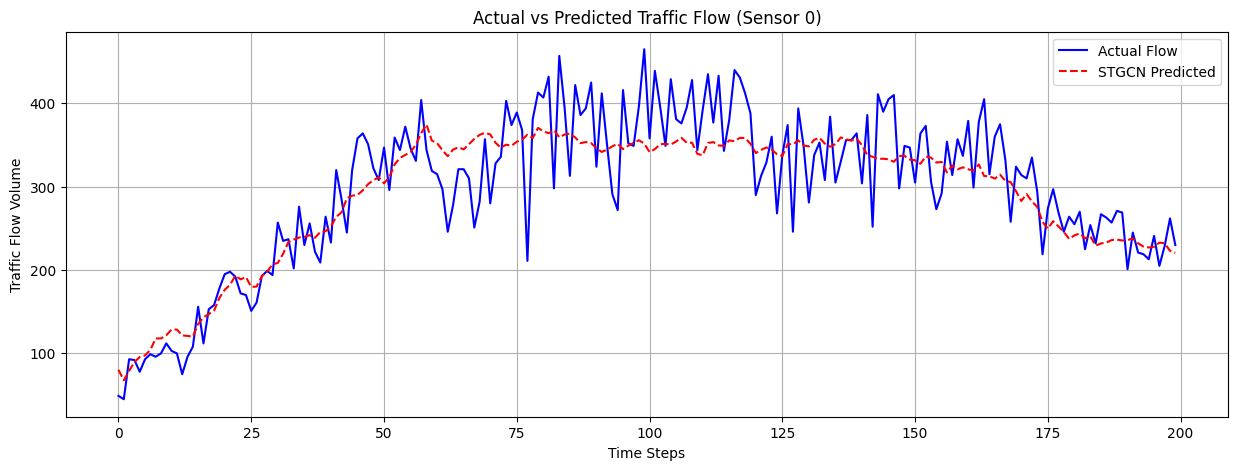

In [28]:
plt.figure(figsize=(15,5))
plt.plot(true_rescaled[:200, 0], label='Actual Flow', color='blue')
plt.plot(preds_rescaled[:200, 0], label='STGCN Predicted', color='red', linestyle='--')
plt.title("Actual vs Predicted Traffic Flow (Sensor 0)")
plt.xlabel("Time Steps")
plt.ylabel("Traffic Flow Volume")
plt.legend()
plt.grid(True)
plt.show()